In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.model_selection import train_test_split

In [10]:
df=pd.read_csv('house_prce.csv')
df

,House_ID,Area_sqft,Bedrooms,Bathrooms,Age_years,Location,Garage,Floors,Distance_to_City_km,Price
0,H001,1200.0,3.0,2.0,10.0,Ludhiana,1.0,1.0,5.2,5200000.0
1,H002,1500.0,3.0,2.0,8.0,Chandigarh,1.0,2.0,7.1,7800000.0
2,H003,950.0,2.0,1.0,15.0,Amritsar,0.0,1.0,4.5,3500000.0
3,H004,1800.0,4.0,3.0,5.0,Mohali,1.0,2.0,8.3,9200000.0
4,H005,1100.0,2.0,2.0,12.0,Jalandhar,1.0,1.0,3.8,4100000.0
5,H006,2200.0,4.0,3.0,3.0,Chandigarh,1.0,2.0,6.4,11500000.0
6,H007,1350.0,3.0,NaN,9.0,Ludhiana,1.0,1.0,4.9,5700000.0
7,H008,1000.0,2.0,1.0,20.0,Amritsar,0.0,1.0,6.2,3100000.0
8,H009,1650.0,3.0,2.0,7.0,Mohali,1.0,2.0,9.1,8500000.0
9,H010,NaN,4.0,3.0,4.0,Chandigarh,1.0,2.0,5.7,10800000.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   House_ID             50 non-null     object 
 1   Area_sqft            48 non-null     float64
 2   Bedrooms             48 non-null     float64
 3   Bathrooms            48 non-null     float64
 4   Age_years            48 non-null     float64
 5   Location             50 non-null     object 
 6   Garage               49 non-null     float64
 7   Floors               48 non-null     float64
 8   Distance_to_City_km  47 non-null     float64
 9   Price                49 non-null     float64
dtypes: float64(8), object(2)
memory usage: 4.0+ KB


In [12]:
df.isnull().count

<bound method DataFrame.count of     House_ID  Area_sqft  Bedrooms  Bathrooms  Age_years  Location  Garage  \
0      False      False     False      False      False     False   False   
1      False      False     False      False      False     False   False   
2      False      False     False      False      False     False   False   
3      False      False     False      False      False     False   False   
4      False      False     False      False      False     False   False   
5      False      False     False      False      False     False   False   
6      False      False     False       True      False     False   False   
7      False      False     False      False      False     False   False   
8      False      False     False      False      False     False   False   
9      False       True     False      False      False     False   False   
10     False      False     False      False      False     False   False   
11     False      False     False      Fals

In [13]:
df.isnull().sum()

House_ID               0
Area_sqft              2
Bedrooms               2
Bathrooms              2
Age_years              2
Location               0
Garage                 1
Floors                 2
Distance_to_City_km    3
Price                  1
dtype: int64

In [16]:
miss_value=df.isnull().sum()/df.shape[0]*100
miss_value

House_ID               0.0
Area_sqft              4.0
Bedrooms               4.0
Bathrooms              4.0
Age_years              4.0
Location               0.0
Garage                 2.0
Floors                 4.0
Distance_to_City_km    6.0
Price                  2.0
dtype: float64

In [19]:
import seaborn as sns

<Axes: >

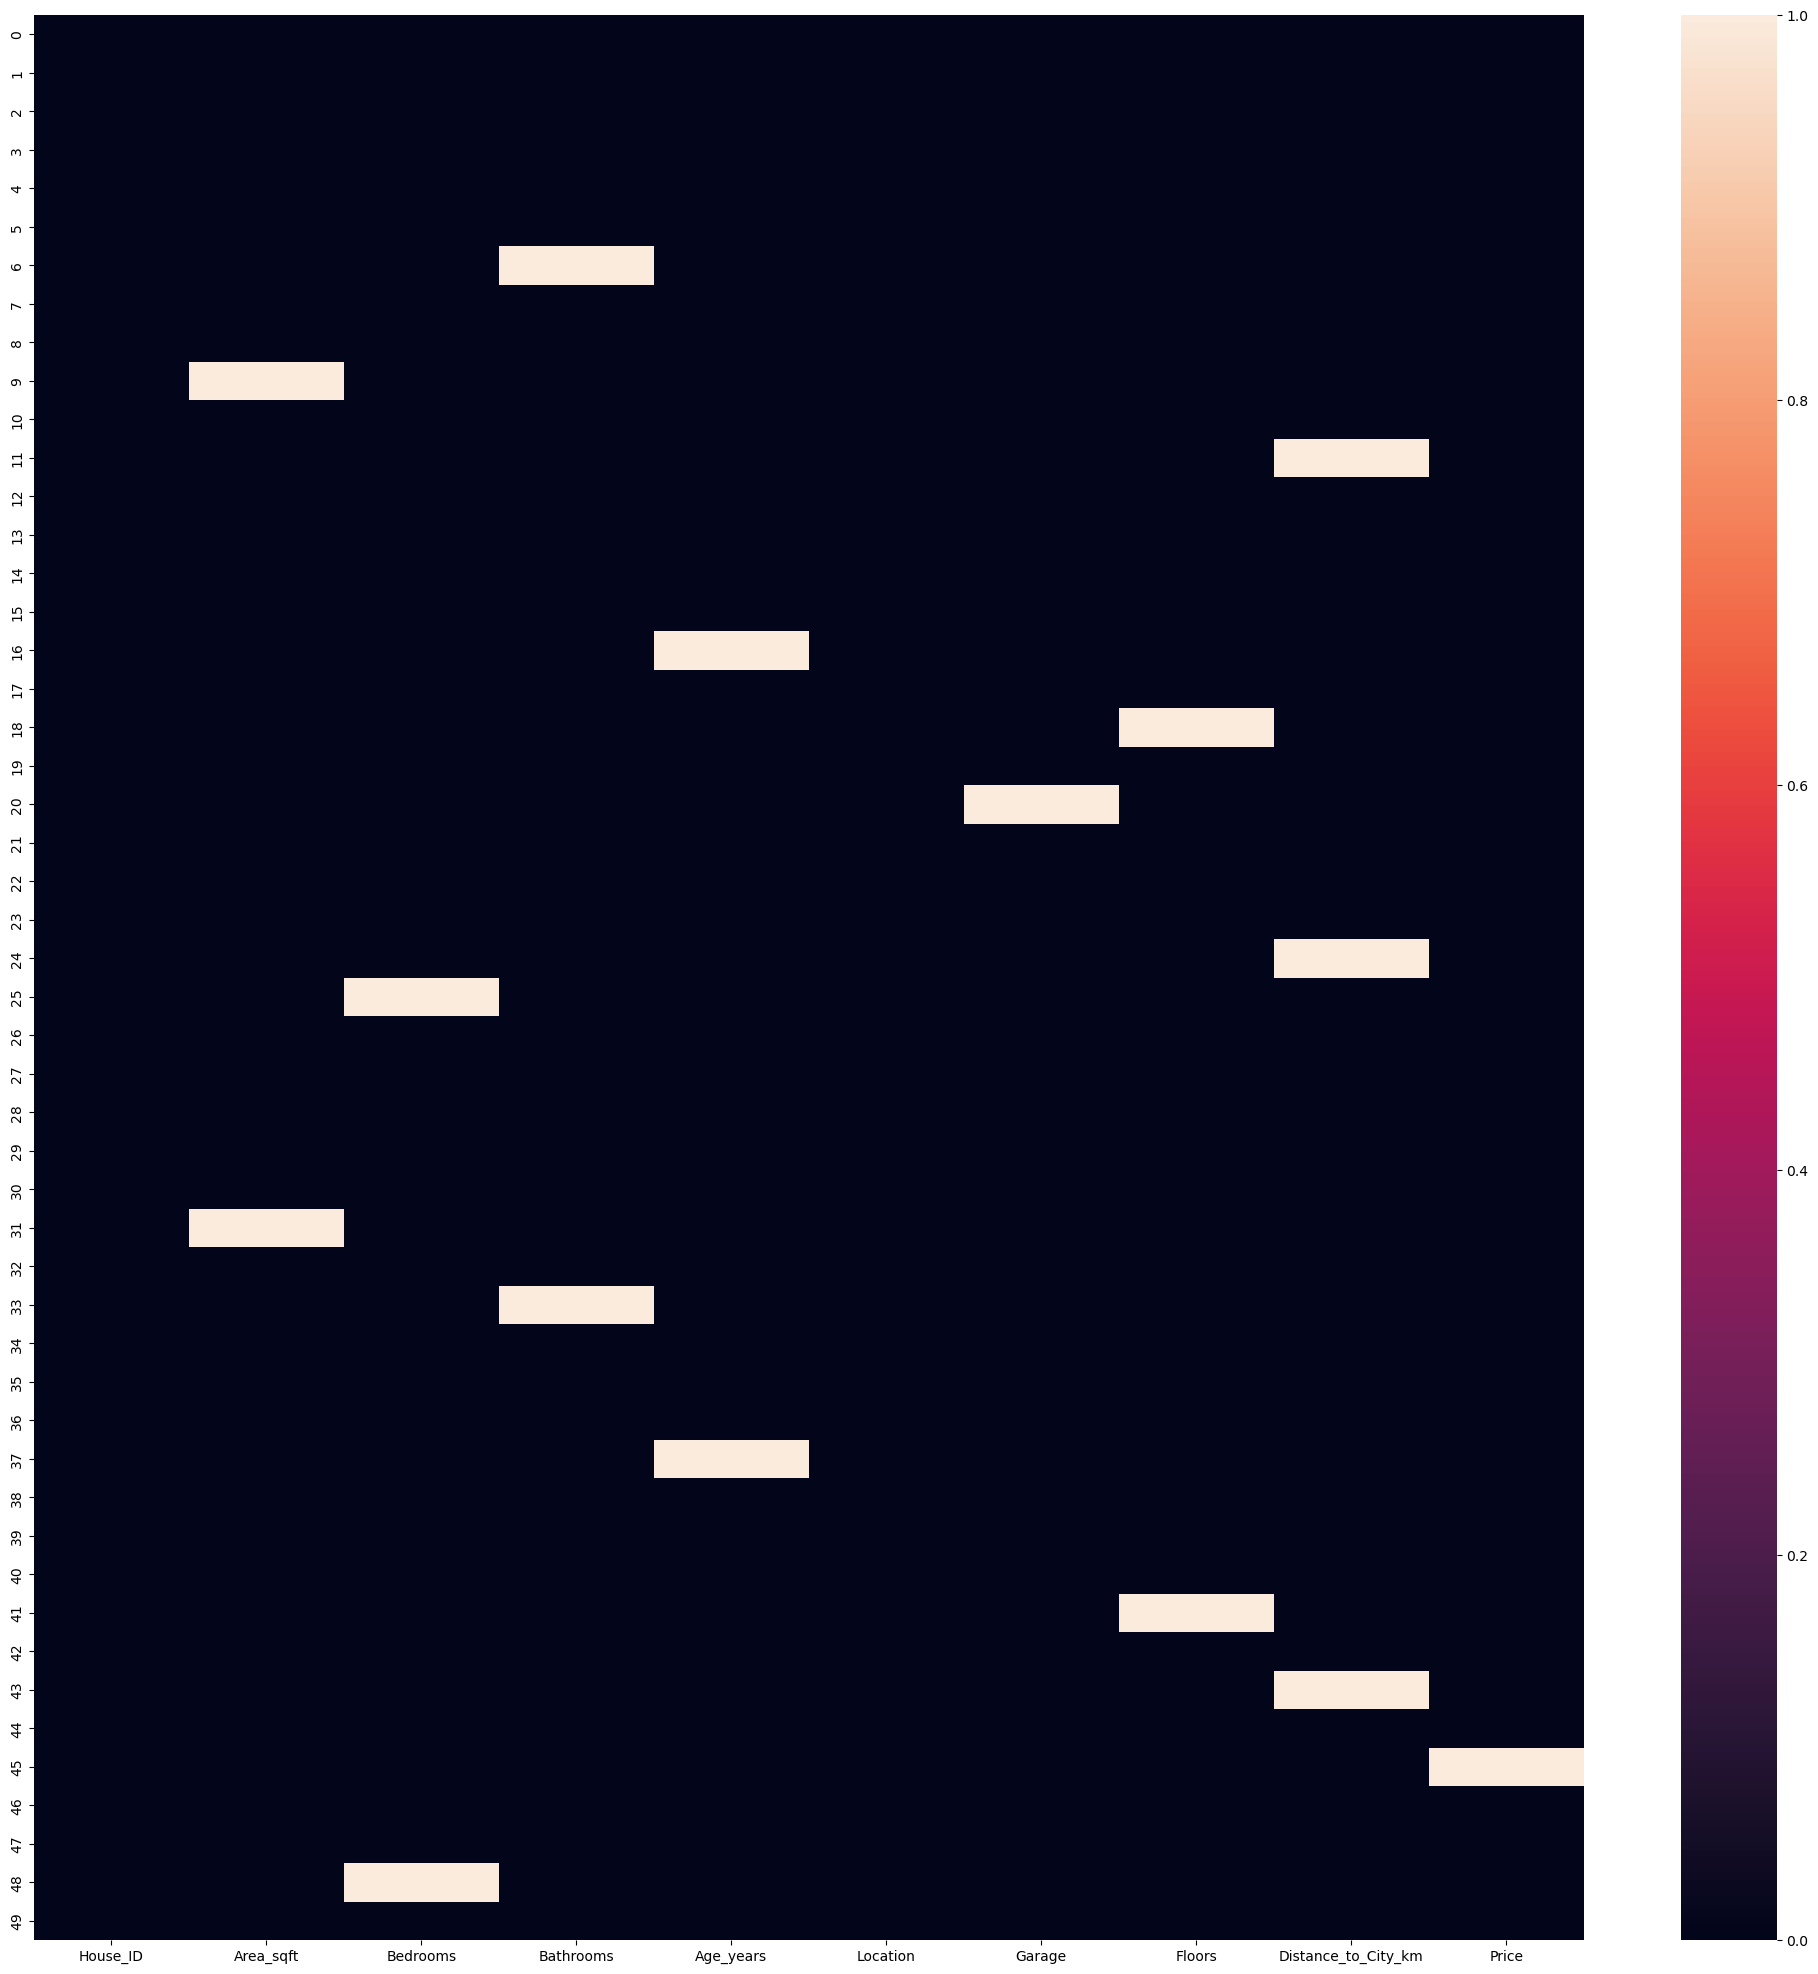

In [20]:
plt.figure(figsize=(25,25))
sns.heatmap(df.isnull())

In [23]:
df=df.dropna()

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   House_ID             35 non-null     object 
 1   Area_sqft            35 non-null     float64
 2   Bedrooms             35 non-null     float64
 3   Bathrooms            35 non-null     float64
 4   Age_years            35 non-null     float64
 5   Location             35 non-null     object 
 6   Garage               35 non-null     float64
 7   Floors               35 non-null     float64
 8   Distance_to_City_km  35 non-null     float64
 9   Price                35 non-null     float64
dtypes: float64(8), object(2)
memory usage: 3.0+ KB


In [25]:
df.isnull().sum()

House_ID               0
Area_sqft              0
Bedrooms               0
Bathrooms              0
Age_years              0
Location               0
Garage                 0
Floors                 0
Distance_to_City_km    0
Price                  0
dtype: int64

<Axes: >

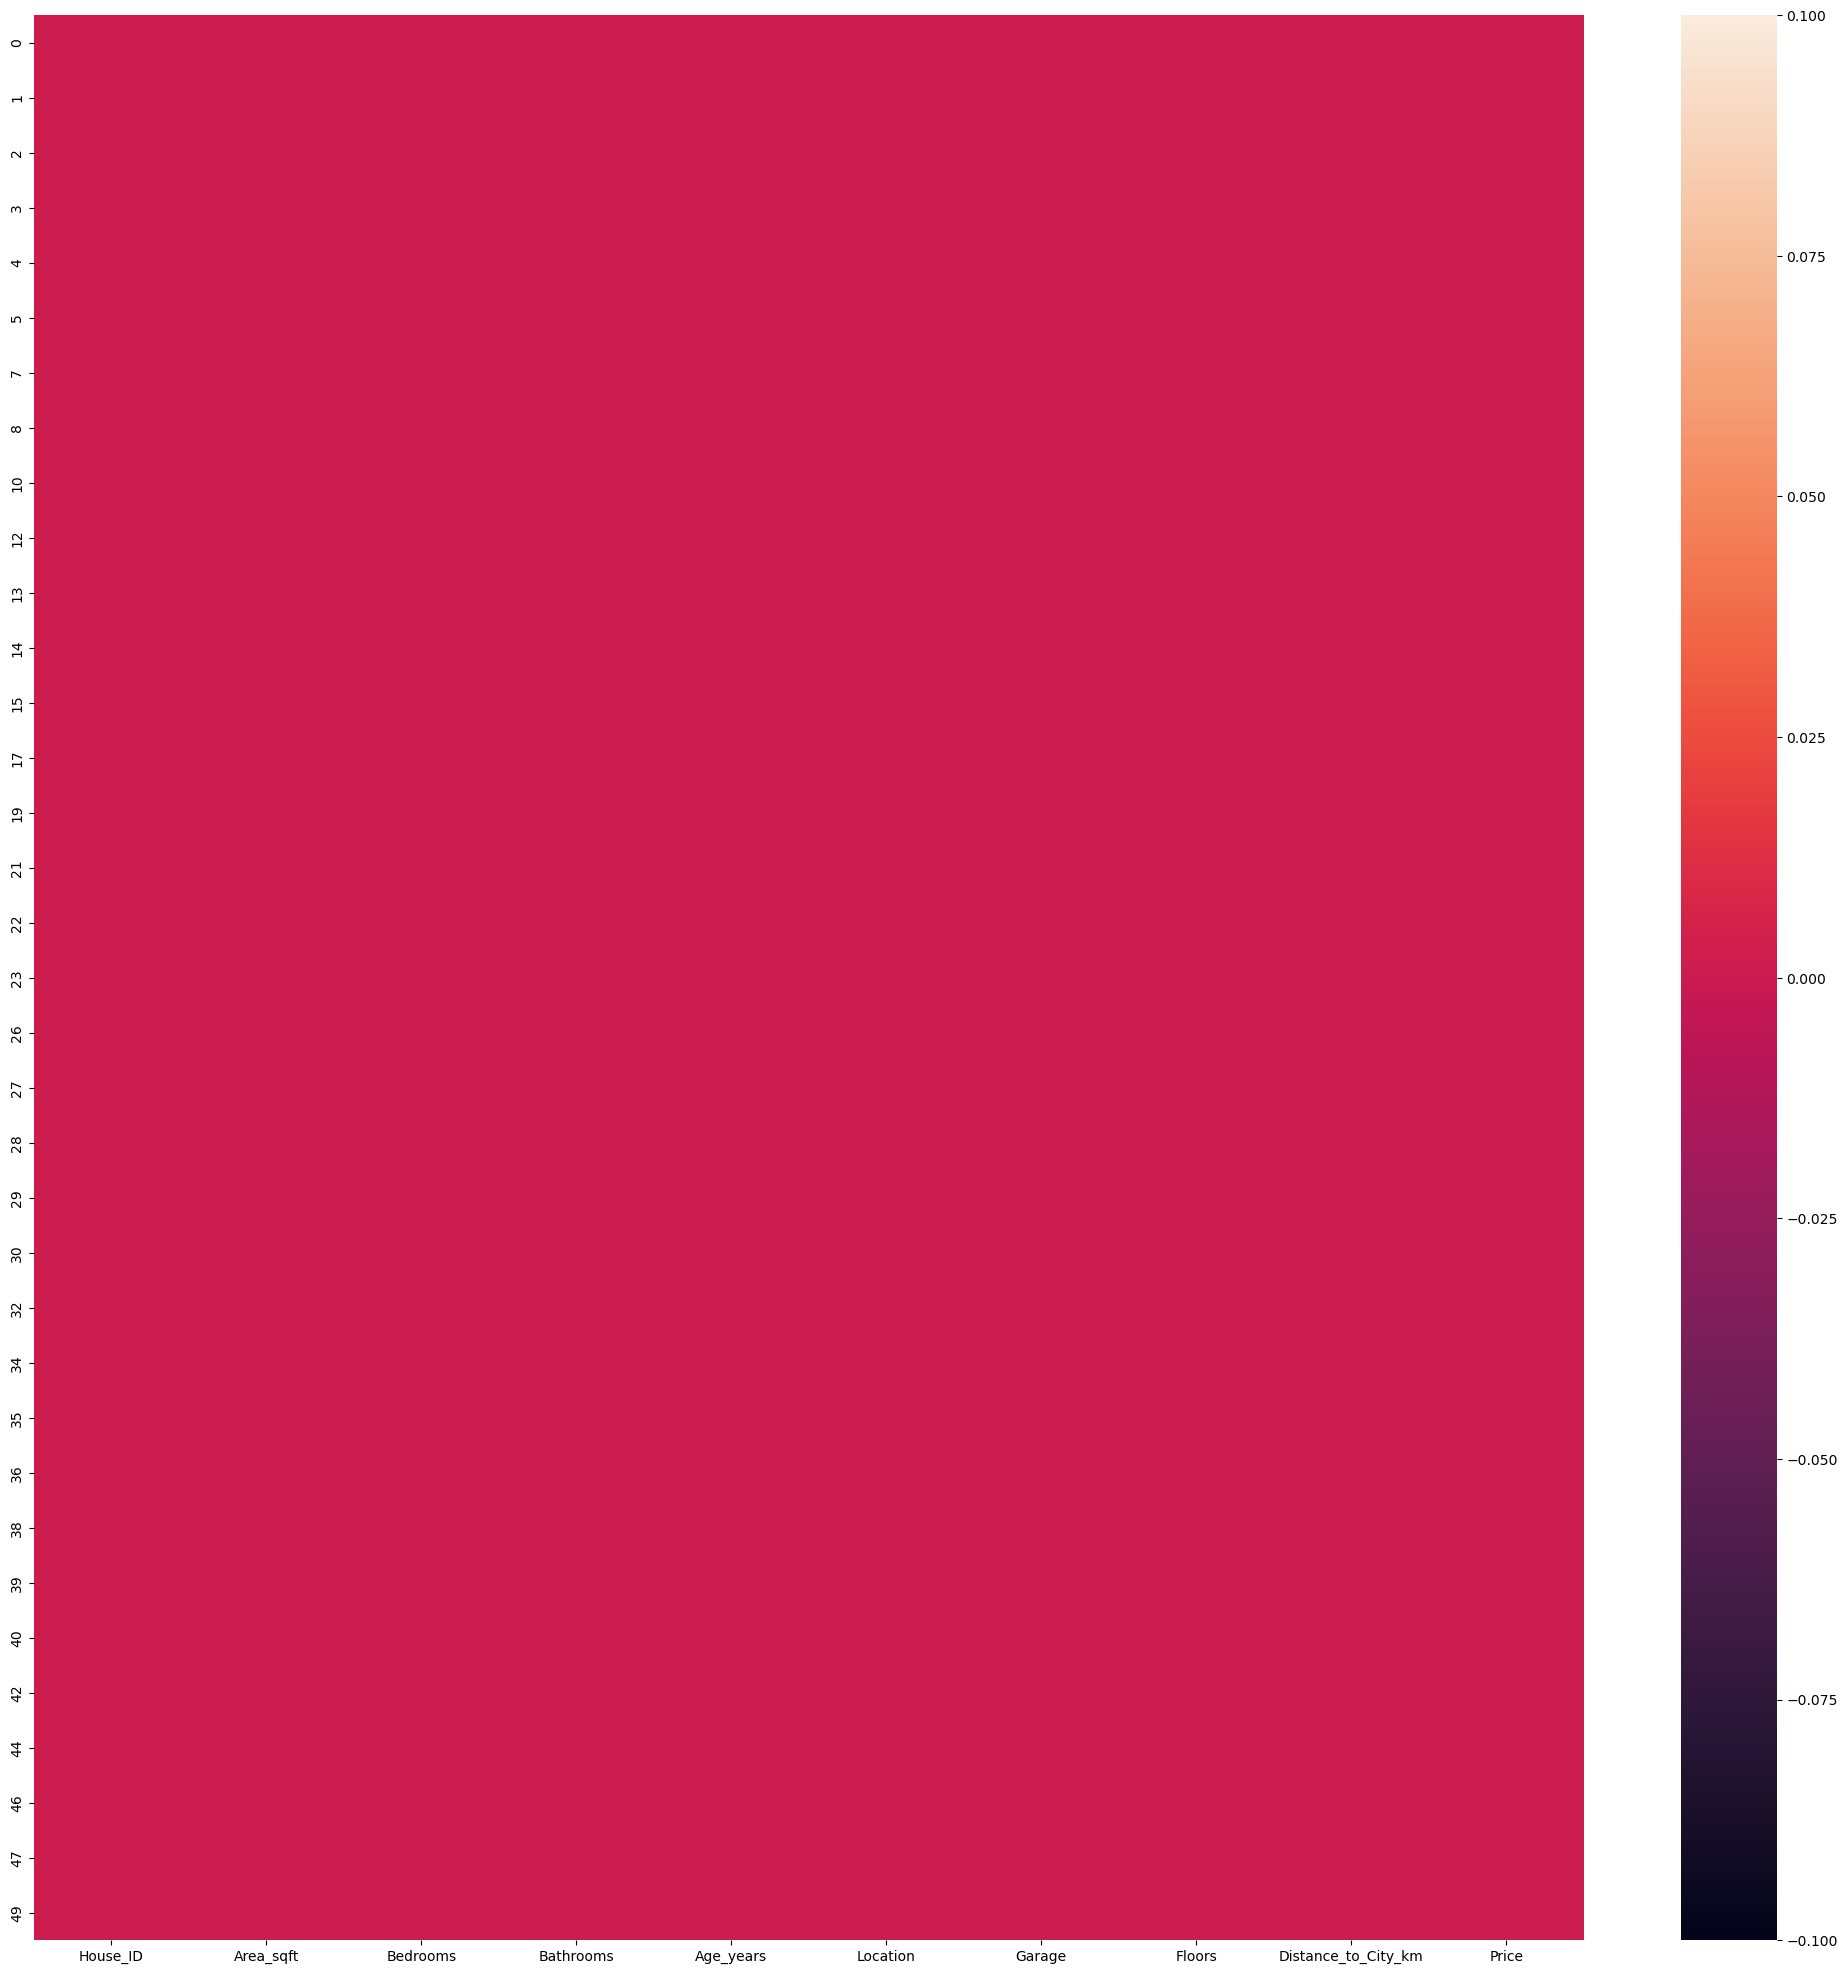

In [27]:
plt.figure(figsize=(25,25))
sns.heatmap(df.isnull())

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   House_ID             35 non-null     object 
 1   Area_sqft            35 non-null     float64
 2   Bedrooms             35 non-null     float64
 3   Bathrooms            35 non-null     float64
 4   Age_years            35 non-null     float64
 5   Location             35 non-null     object 
 6   Garage               35 non-null     float64
 7   Floors               35 non-null     float64
 8   Distance_to_City_km  35 non-null     float64
 9   Price                35 non-null     float64
dtypes: float64(8), object(2)
memory usage: 3.0+ KB


In [50]:
X=df.drop(columns=['House_ID','Location','Price'])
X.shape

(35, 7)

In [51]:
y=df['Price']
y.shape

(35,)

In [52]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [53]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(28, 7)
(7, 7)
(28,)
(7,)


In [54]:
model=LinearRegression()

In [55]:
df.sample()

,House_ID,Area_sqft,Bedrooms,Bathrooms,Age_years,Location,Garage,Floors,Distance_to_City_km,Price
46,H047,1070.0,2.0,1.0,18.0,Amritsar,0.0,1.0,7.1,3200000.0


In [58]:
df.corr(numeric_only=True)

,Area_sqft,Bedrooms,Bathrooms,Age_years,Garage,Floors,Distance_to_City_km,Price
Area_sqft,1.000000,0.939059,0.926784,-0.919700,0.666367,0.877122,-0.182176,0.984589
Bedrooms,0.939059,1.000000,0.932358,-0.901610,0.699879,0.813886,-0.189980,0.928510
Bathrooms,0.926784,0.932358,1.000000,-0.924803,0.816685,0.793229,-0.299094,0.922056
Age_years,-0.919700,-0.901610,-0.924803,1.000000,-0.829006,-0.847575,0.307128,-0.925016
Garage,0.666367,0.699879,0.816685,-0.829006,1.000000,0.580381,-0.375112,0.653484
Floors,0.877122,0.813886,0.793229,-0.847575,0.580381,1.000000,0.063762,0.902435
Distance_to_City_km,-0.182176,-0.189980,-0.299094,0.307128,-0.375112,0.063762,1.000000,-0.202913
Price,0.984589,0.928510,0.922056,-0.925016,0.653484,0.902435,-0.202913,1.000000


<Axes: >

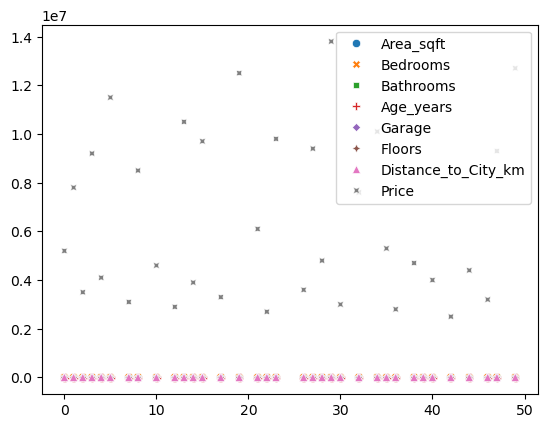

In [59]:
sns.scatterplot(data=df)

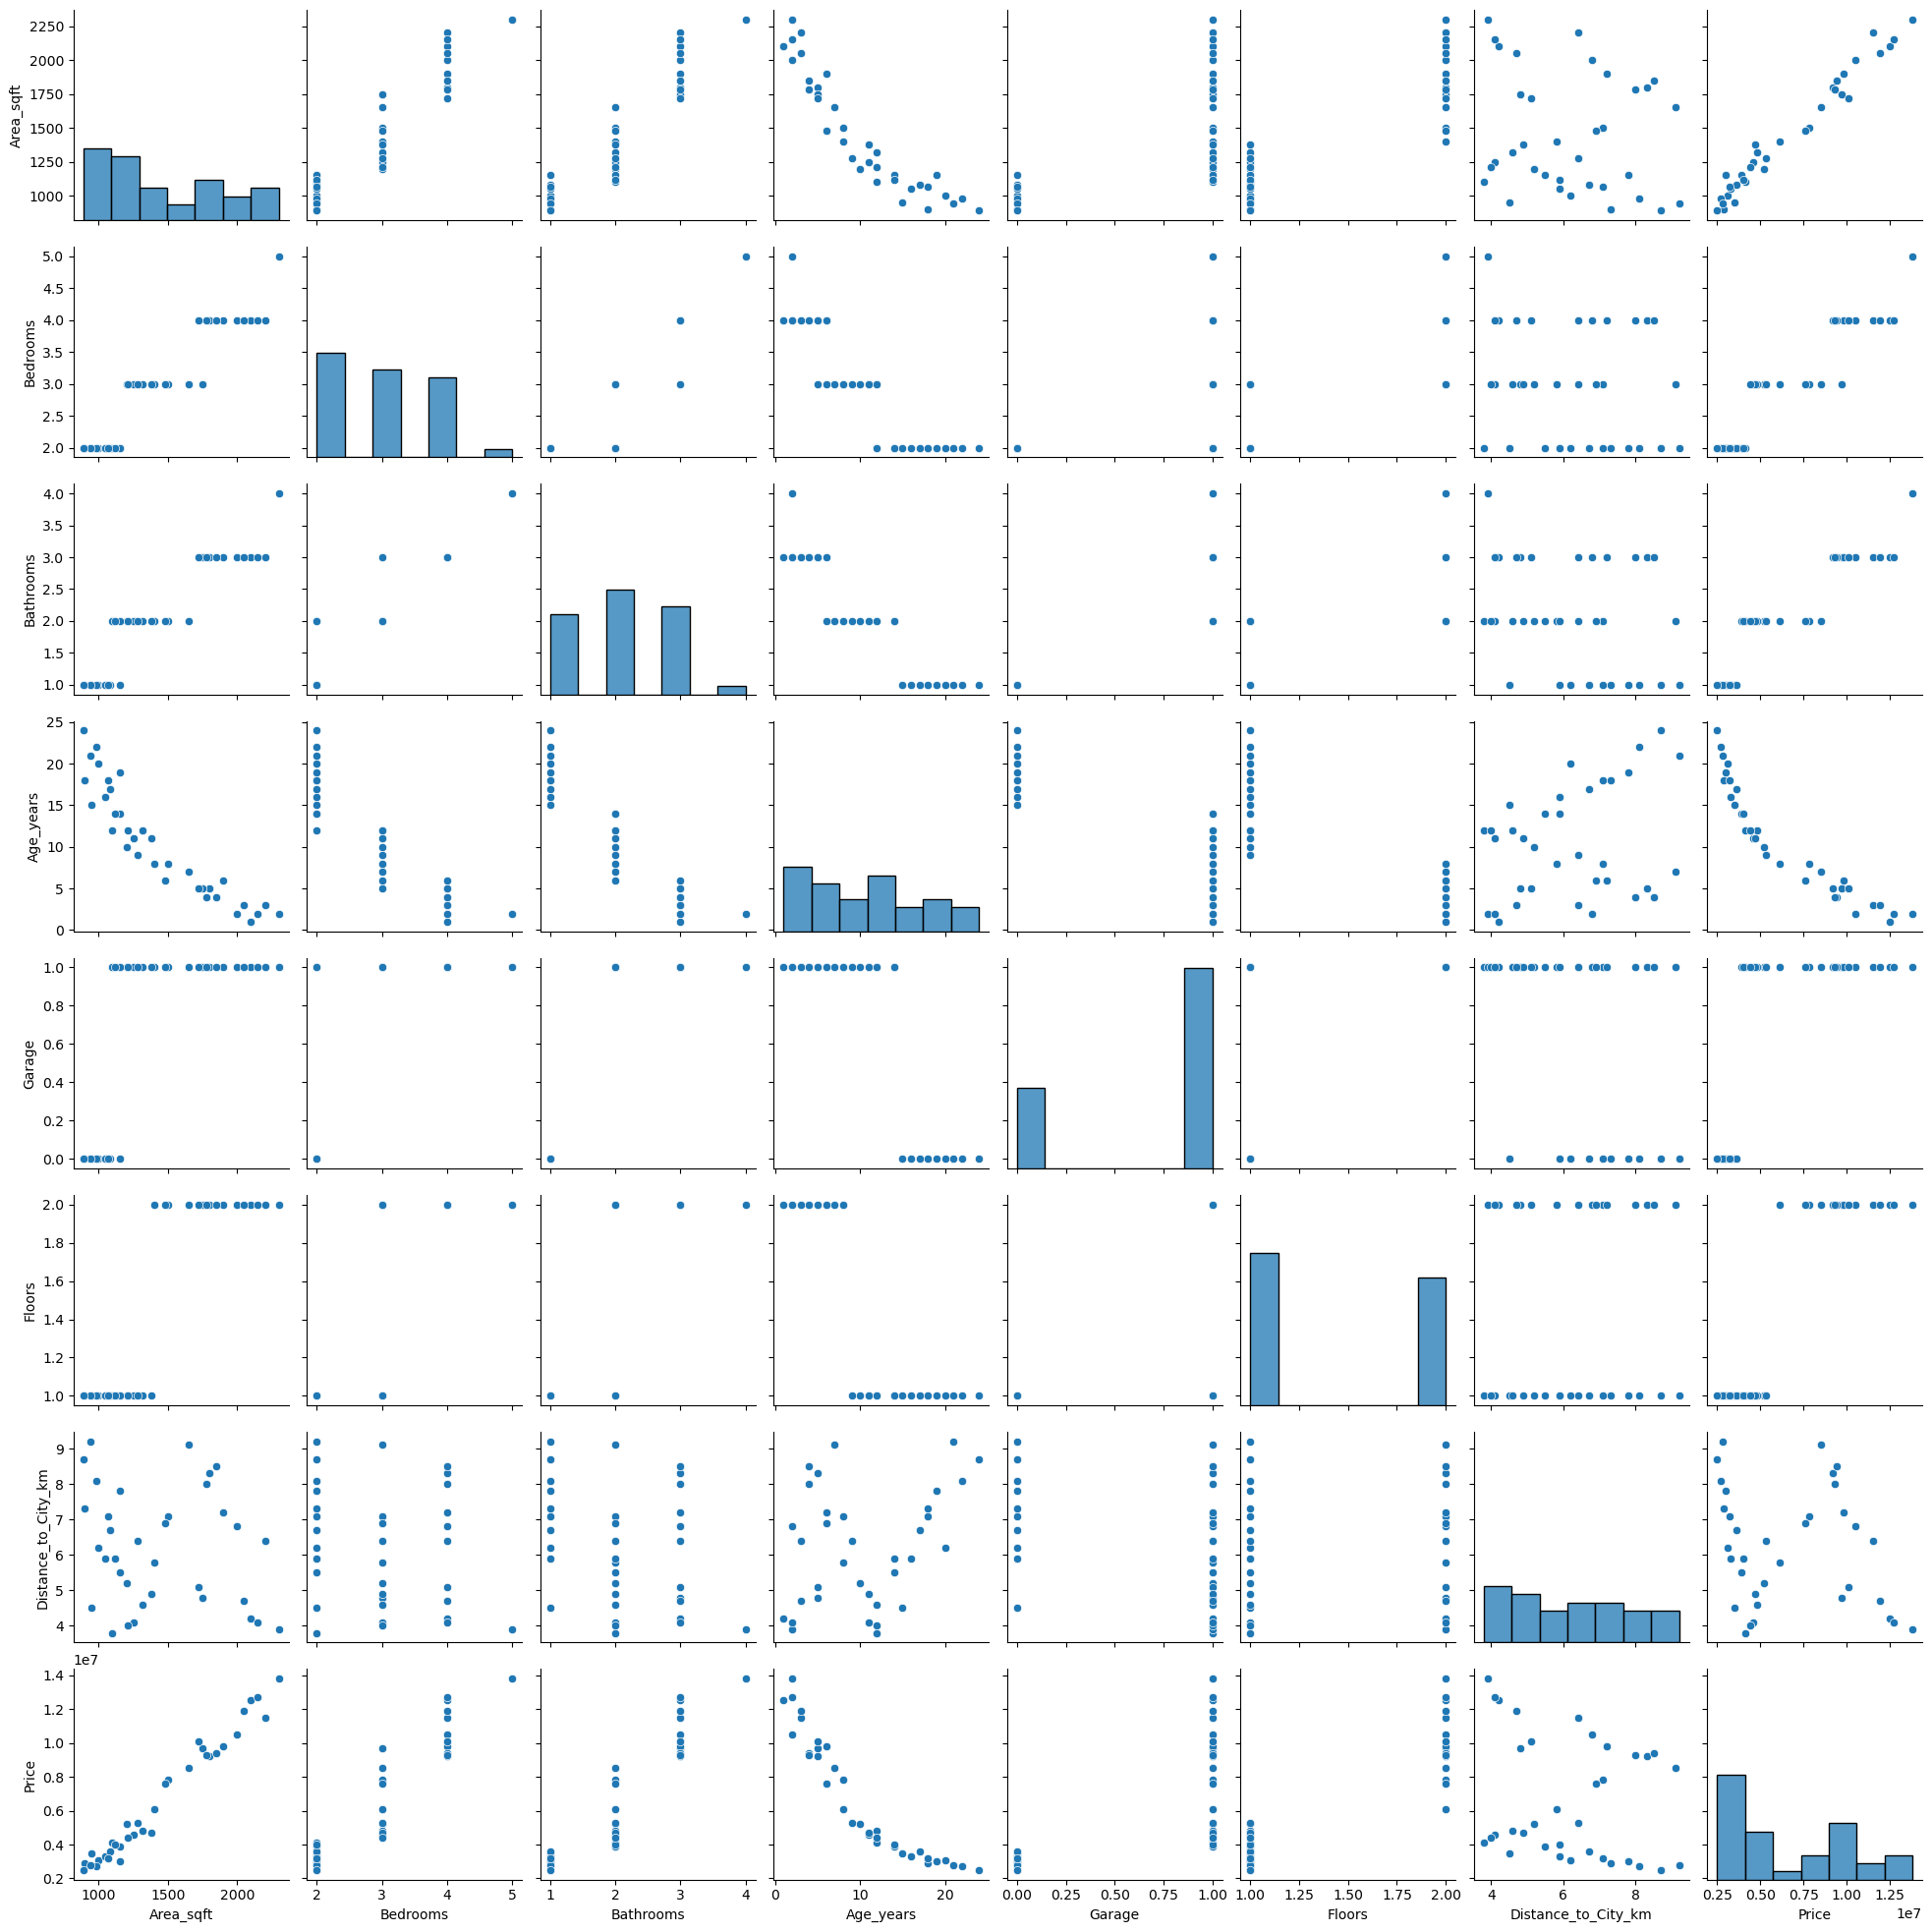

In [60]:
sns.pairplot(data=df)

In [61]:
df.corr(numeric_only=True)

,Area_sqft,Bedrooms,Bathrooms,Age_years,Garage,Floors,Distance_to_City_km,Price
Area_sqft,1.000000,0.939059,0.926784,-0.919700,0.666367,0.877122,-0.182176,0.984589
Bedrooms,0.939059,1.000000,0.932358,-0.901610,0.699879,0.813886,-0.189980,0.928510
Bathrooms,0.926784,0.932358,1.000000,-0.924803,0.816685,0.793229,-0.299094,0.922056
Age_years,-0.919700,-0.901610,-0.924803,1.000000,-0.829006,-0.847575,0.307128,-0.925016
Garage,0.666367,0.699879,0.816685,-0.829006,1.000000,0.580381,-0.375112,0.653484
Floors,0.877122,0.813886,0.793229,-0.847575,0.580381,1.000000,0.063762,0.902435
Distance_to_City_km,-0.182176,-0.189980,-0.299094,0.307128,-0.375112,0.063762,1.000000,-0.202913
Price,0.984589,0.928510,0.922056,-0.925016,0.653484,0.902435,-0.202913,1.000000


In [62]:
model.fit(X_train,y_train)

LinearRegression()

In [63]:
model.predict(X_test)

array([ 2172882.37774738,  3760879.31698193,  9787879.32100355,
       13168080.78666674,  7671108.7817165 ,  3560340.26228438,
        9695812.66905564])

In [64]:
model.score(X_test,y_test)

0.9625016514037691

In [65]:
df.sample()

,House_ID,Area_sqft,Bedrooms,Bathrooms,Age_years,Location,Garage,Floors,Distance_to_City_km,Price
29,H030,2300.0,5.0,4.0,2.0,Chandigarh,1.0,2.0,3.9,13800000.0


In [79]:
area=float(input("enter area:"))
bedroom=float(input("enter no. of bedroom:"))
bathroom=float(input("enter no. of bathroom:"))
age=float(input("enter your age:"))
garage=float(input("enter no. of garage:"))
floors=float(input("enter no. of floors:"))
distance=float(input("enter distance:"))
data=[[area,bedroom,bathroom,age,garage,floors,distance]]
prediction=model.predict(data)
prediction.round(2)
print(f"model score: {round(model.score(X_test, y_test)*100, 2)} %")

enter area: 2300
enter no. of bedroom: 5
enter no. of bathroom: 4
enter your age: 2
enter no. of garage: 1
enter no. of floors: 2
enter distance: 3.9


model score: 96.25 %


C:\Users\piyus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [78]:
print(f"model score: {round(model.score(X_test, y_test)*100, 2)} %")

model score: 96.25 %
